# Méthode d'aggrégation

## Littérature sur la valeurs fonciéres

## Visualisation exploratoire

In [36]:
#Importation des packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pygwalker as pyg

In [37]:
#Importation de la base de donnée & visualisation préalable
data = pd.read_csv("./small_train.csv")
data.sample(10)

,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,...,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
7648,1,24/10/2023,Vente,325688.0,2.0,NaN,CITE,A016,DE SAINT-AIGNY,36300.0,...,NaN,NaN,0,1.0,Maison,54.0,3.0,S,NaN,6076.0
2810,1,08/03/2023,Vente,14150.0,NaN,NaN,NaN,B061,LE PUY,84220.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,L,NaN,920.0
7682,1,11/04/2023,Vente,60000.0,NaN,NaN,NaN,B043,LE PETIT MONGUILLET,33790.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,P,NaN,3509.0
8487,1,04/10/2023,Vente,40000.0,174.0,NaN,BD,0229,DE SAINT RAPHAEL,83420.0,...,NaN,NaN,1,3.0,Dépendance,0.0,0.0,NaN,NaN,NaN
159,1,15/12/2023,Vente,286500.0,14.0,NaN,LOT,A046,LES HAM DE PORT DE BOUC,13110.0,...,NaN,NaN,0,1.0,Maison,90.0,5.0,S,NaN,400.0
1464,1,20/02/2023,Vente,140000.0,9013.0,NaN,RUE,0345,DU VAL DE LA TUILERIE,54340.0,...,NaN,NaN,0,3.0,Dépendance,0.0,0.0,S,NaN,250.0
7275,1,15/12/2023,Vente,99620.0,14.0,NaN,AV,0440,CAMILLE PELLETAN,17300.0,...,NaN,NaN,1,2.0,Appartement,30.0,1.0,NaN,NaN,NaN
1025,1,05/01/2023,Vente,123600.0,NaN,NaN,NaN,B066,LA ROCHE,26170.0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,VI,VAOC,6920.0
5032,1,07/07/2023,Vente,243500.0,29.0,NaN,RUE,0043,DU GRAND CONTOUR,39380.0,...,NaN,NaN,0,3.0,Dépendance,0.0,0.0,S,NaN,1857.0
747,1,31/03/2023,Vente,29000.0,32.0,NaN,RUE,1449,DE LA MEDITERRANEE,83600.0,...,NaN,NaN,1,3.0,Dépendance,0.0,0.0,NaN,NaN,NaN


In [38]:
data = data.drop('Date mutation', axis=1)
data = data.drop('No disposition', axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nature mutation             10000 non-null  object 
 1   Valeur fonciere             10000 non-null  float64
 2   No voie                     6156 non-null   float64
 3   B/T/Q                       433 non-null    object 
 4   Type de voie                5940 non-null   object 
 5   Code voie                   9911 non-null   object 
 6   Voie                        9911 non-null   object 
 7   Code postal                 9910 non-null   float64
 8   Commune                     10000 non-null  object 
 9   Code departement            10000 non-null  object 
 10  Code commune                10000 non-null  int64  
 11  Prefixe de section          470 non-null    float64
 12  Section                     9998 non-null   object 
 13  No plan                     1000

## Etudes statistique exploratoire

In [85]:
pyg.walk(data)

Box(children=(HTML(value='\n<div id="ifr-pyg-00062d7d3ae27057BidwnNRToS1IK2WQ" style="height: auto">\n    <hea…

## Etude des corrélations

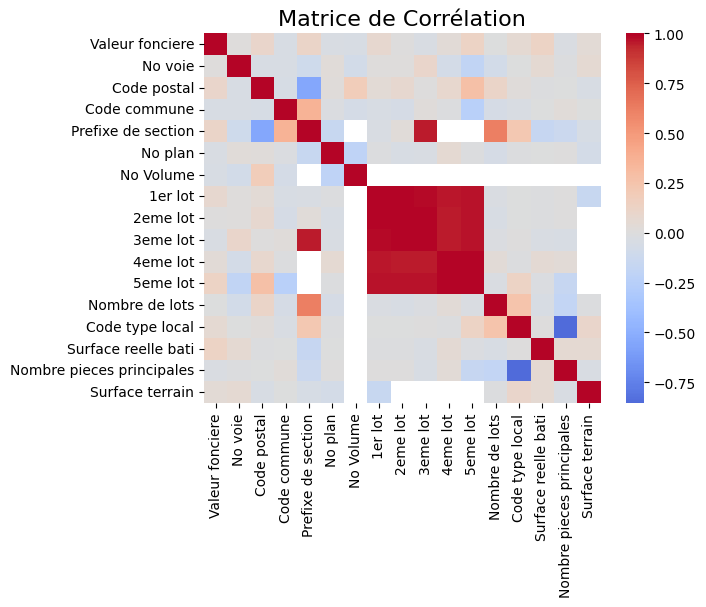

In [39]:
numerique_data = data.select_dtypes(include='number')
correlation = numerique_data.corr()
sns.heatmap(correlation, annot=False, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation', fontsize=16)
plt.show()

### Visualisation de la valeurs foncière

/var/folders/jq/dwvfq6hd6cb00_ztp8scl1_h0000gn/T/ipykernel_6127/870569902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type local', y='Valeur fonciere', data=data, palette='Set2')


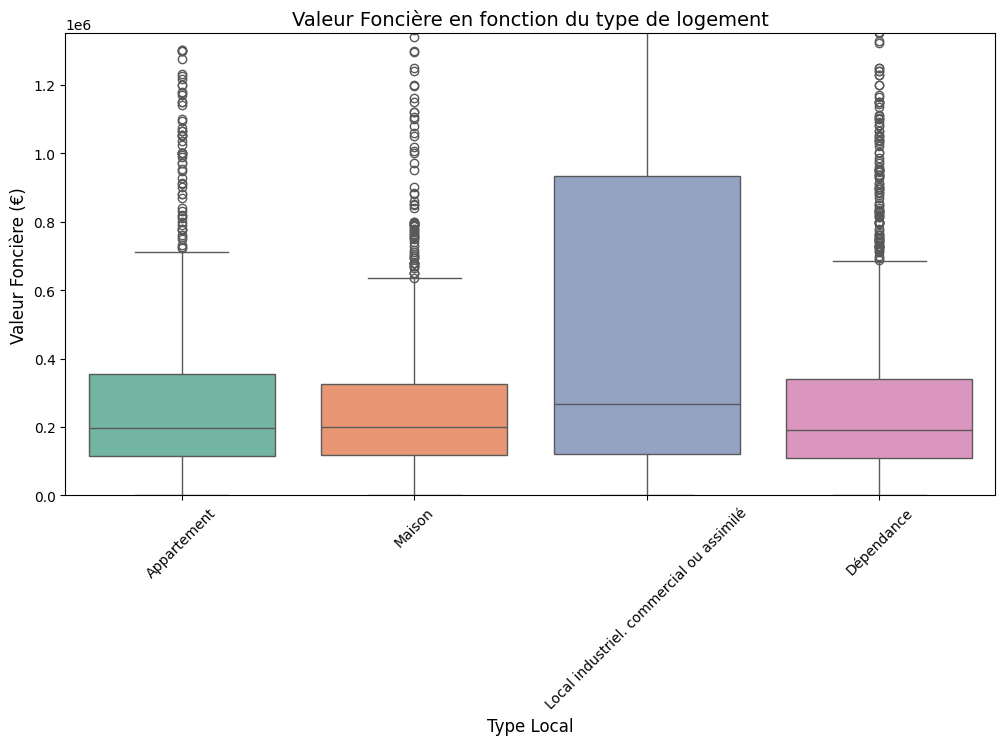

In [40]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Type local', y='Valeur fonciere', data=data, palette='Set2')
plt.title('Valeur Foncière en fonction du type de logement', fontsize=14)
plt.xlabel('Type Local', fontsize=12)
plt.ylabel('Valeur Foncière (€)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, data['Valeur fonciere'].quantile(0.95))  # Exclure les valeurs extrêmes
plt.show()

### Visualisation cartographique

In [41]:
france_map = gpd.read_file('https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson')
transactions_par_dep = data['Code departement'].value_counts().reset_index()
transactions_par_dep.columns = ['code', 'transactions']
transactions_par_dep['code'] = transactions_par_dep['code'].astype(str)
france_map['code'] = france_map['code'].astype(str)
france_map = france_map.merge(transactions_par_dep, on='code', how='left')
france_map['transactions'] = france_map['transactions'].fillna(0)  # Remplir les valeurs manquantes avec 0

#### Nombre de transaction par département

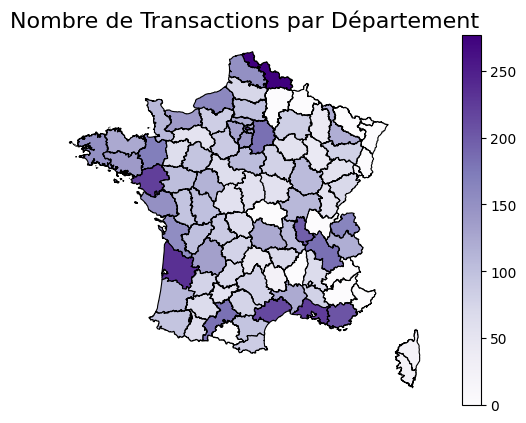

In [42]:
ax = france_map.plot(column='transactions', 
                     cmap='Purples', 
                     linewidth=0.8, 
                     edgecolor='black', 
                     legend=True)

plt.title('Nombre de Transactions par Département', fontsize=16)
plt.axis('off')
plt.show()

#### Valeur moyenne des ventes par département

In [43]:
prix_moyen_par_dep = data.groupby('Code departement')['Valeur fonciere'].mean().reset_index()
prix_moyen_par_dep.columns = ['code', 'prix_moyen']
prix_moyen_par_dep['code'] = prix_moyen_par_dep['code'].astype(str)
france_map = france_map.merge(prix_moyen_par_dep, on='code', how='left')
france_map['prix_moyen'] = france_map['prix_moyen'].fillna(0)

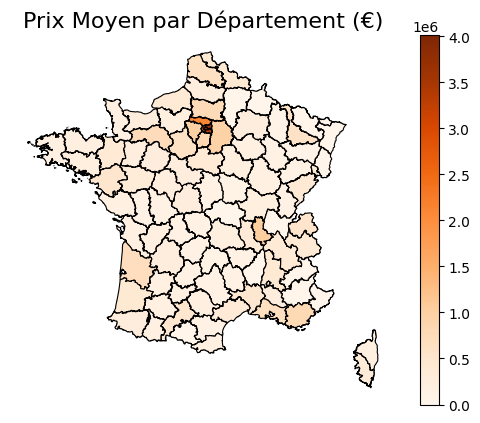

In [44]:
ax = france_map.plot(column='prix_moyen', 
                     cmap='Oranges', 
                     linewidth=0.8, 
                     edgecolor='black', 
                     legend=True)

plt.title('Prix Moyen par Département (€)', fontsize=16)
plt.axis('off')
plt.show()

## Visualisation des variables manquantes & Nettoyage des données 

In [49]:
NA = data.isnull().mean() * 100
NA = NA[NA > 0]
print("Pourcentage de données manquantes par colonne :")
print(NA)

Pourcentage de données manquantes par colonne :
No voie                       38.44
B/T/Q                         95.67
Type de voie                  40.60
Code voie                      0.89
Voie                           0.89
Code postal                    0.90
Prefixe de section            95.30
Section                        0.02
No Volume                     99.76
1er lot                       69.49
Surface Carrez du 1er lot     91.43
2eme lot                      90.20
Surface Carrez du 2eme lot    96.93
3eme lot                      98.01
Surface Carrez du 3eme lot    99.64
4eme lot                      99.41
Surface Carrez du 4eme lot    99.92
5eme lot                      99.78
Surface Carrez du 5eme lot    99.98
Code type local               42.29
Type local                    42.29
Surface reelle bati           42.36
Nombre pieces principales     42.36
Nature culture                30.95
Nature culture speciale       95.08
Surface terrain               30.95
dtype: float64


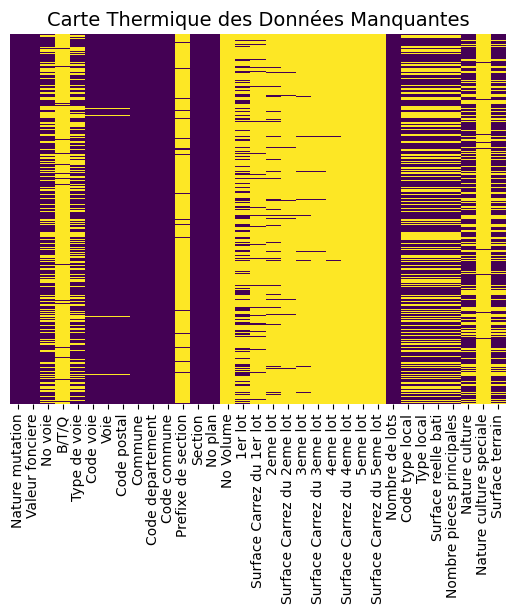

In [50]:
#Visualisation des valeurs manquantes
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Carte Thermique des Données Manquantes', fontsize=14)
plt.show()

### 1er étape supprésion des variable de plus de 40% de NA

In [51]:
seuil = 0.5
ratio_NA = data.isnull().mean()
variable_50 = ratio_NA[ratio_NA > seuil].index
print(f"Variables supprimées (plus de {seuil*100}% de valeurs manquantes) : {list(variable_50)}")
data.drop(columns=variable_50, inplace=True)

Variables supprimées (plus de 50.0% de valeurs manquantes) : ['B/T/Q', 'Prefixe de section', 'No Volume', '1er lot', 'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot', '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot', 'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot', 'Nature culture speciale']


### Sélection des variables par catégorie

In [52]:
#Sélection des variables 
variable_num = data.select_dtypes(include=np.number).columns
variable_num_na = [col for col in variable_num if data[col].isnull().sum() > 0]
variable_cat = data.select_dtypes(include='object').columns
variable_cat_na = [col for col in variable_cat if data[col].isnull().sum() > 0]
print("Variables numériques av`ec NA :", variable_num_na)
print("Variables catégorielles avec NA :", variable_cat_na)
print(f"Nombre de valeurs manquantes avant traitement :\n{data.isnull().sum()}")

Variables numériques av`ec NA : ['No voie', 'Code postal', 'Code type local', 'Surface reelle bati', 'Nombre pieces principales', 'Surface terrain']
Variables catégorielles avec NA : ['Type de voie', 'Code voie', 'Voie', 'Section', 'Type local', 'Nature culture']
Nombre de valeurs manquantes avant traitement :
Nature mutation                 0
Valeur fonciere                 0
No voie                      3844
Type de voie                 4060
Code voie                      89
Voie                           89
Code postal                    90
Commune                         0
Code departement                0
Code commune                    0
Section                         2
No plan                         0
Nombre de lots                  0
Code type local              4229
Type local                   4229
Surface reelle bati          4236
Nombre pieces principales    4236
Nature culture               3095
Surface terrain              3095
dtype: int64


In [60]:
# Imputation du N° voie par la loi de Benfort
distribution_de_benfort = {digit: np.log10(1 + 1 / digit) for digit in range(1, 10)}
def generate_benford_values(size):
    digits = np.array(list(distribution_de_benfort.keys()))
    probabilité = np.array(list(distribution_de_benfort.values()))
    return np.random.choice(digits, size=size, p=probabilité)
NA = data['No voie'].isnull()
Benfort_valeur = generate_benford_values(NA.sum())
data.loc[NA, 'No voie'] = Benfort_valeur
# Imputation logique de 'Code postal' basé sur la commune
data['Code postal'] = data.groupby('Commune')['Code postal'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 0))

# Imputation de 'Surface terrain' basé sur la géographie
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
geo_columns = ['Code postal', 'Code departement', 'Code commune']
label_encoder = LabelEncoder()
for col in geo_columns:
    if data[col].dtype == 'object':
        data[col] = label_encoder.fit_transform(data[col].astype(str))
subset_for_imputation_1 = data[geo_columns + ['Surface terrain']]
knn_imputer = KNNImputer(n_neighbors=5)
data['Surface terrain'] = knn_imputer.fit_transform(subset_for_imputation_1[['Code postal', 'Code departement', 'Code commune', 'Surface terrain']])[:, -1]

# Imputation de 'Surface reelle bati' basé sur la géographie / Surface terrain / Type de Voie
geo_surface_columns = ['Code postal', 'Code departement', 'Code commune','Surface terrain','Type de voie']
label_encoder = LabelEncoder()
for col in geo_surface_columns:
    if data[col].dtype == 'object':
        data[col] = label_encoder.fit_transform(data[col].astype(str))
subset_for_imputation_2 = data[geo_surface_columns + ['Surface reelle bati']]
data['Surface reelle bati'] = knn_imputer.fit_transform(subset_for_imputation_2[['Code postal', 'Code departement', 'Code commune','Surface terrain','Type de voie','Surface reelle bati']])[:, -1]

# Fonction pour imputer les valeurs manquantes dans 'Nature culture' en fonction de la distribution de cette même variable par département
def imputer_par_distribution(df, column, group_column):
    df_copy = df.copy()
    for dept, group in df_copy.groupby(group_column):
        distribution = group[column].value_counts(normalize=True)
        missing_indices = group[group[column].isna()].index
        if len(missing_indices) > 0:
            imputed_values = np.random.choice(distribution.index, 
                                              size=len(missing_indices), 
                                              p=distribution.values)
            df_copy.loc[missing_indices, column] = imputed_values
    return df_copy
data = imputer_par_distribution(data, 'Nature culture', 'Code departement')
data = imputer_par_distribution(data, 'Type de voie', 'Code departement')
data = imputer_par_distribution(data, 'Type local', 'Code departement')
data = imputer_par_distribution(data, 'Code type local', 'Code departement')

# Imputation de 'Nombre de pièce' basé sur la géographie / Surface terrain
geo_surface_local_columns = ['Code postal', 'Code departement', 'Code commune','Surface terrain','Surface reelle bati','Type de voie']
label_encoder = LabelEncoder()
for col in geo_surface_columns:
    if data[col].dtype == 'object':
        data[col] = label_encoder.fit_transform(data[col].astype(str))
subset_for_imputation_3 = data[geo_surface_local_columns + ['Nombre pieces principales']]
data['Nombre pieces principales'] = knn_imputer.fit_transform(subset_for_imputation_3[['Nombre pieces principales',
                                                                                    'Code postal', 'Code departement', 'Code commune','Surface terrain','Surface reelle bati',
                                                                                     'Type de voie']])[:, -1]

# Imputation de 'Code voie' et 'Voie' basé sur 'No voie'
data['Code voie'] = data['Code voie'].fillna(data.groupby('No voie')['Code voie'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Inconnu'))
data['Voie'] = data['Voie'].fillna(data.groupby('No voie')['Voie'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Inconnu'))

# Imputation de 'Section' par la modalité la plus fréquente dans la même Commune
data['Section'] = data.groupby('Commune')['Section'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Inconnue'))

Nombre de valeurs manquantes aprés traitement :
Nature mutation              0
Valeur fonciere              0
No voie                      0
Type de voie                 0
Code voie                    0
Voie                         0
Code postal                  0
Commune                      0
Code departement             0
Code commune                 0
Section                      0
No plan                      0
Nombre de lots               0
Code type local              0
Type local                   0
Surface reelle bati          0
Nombre pieces principales    0
Nature culture               0
Surface terrain              0
dtype: int64


### Ajout de variable binaire pouvant impacter la valeur fonciére

In [67]:
#Département proche de la mer
departements_littoraux = ['59','62','80','76','27','14','50','35','22','29'
                          ,'56','44','85','17','33','40','64'
                          ,'66','11','34','30','13','83','6','2'
]
data['proche_mer'] = data['Code departement'].apply(lambda x: 1 if str(x) in departements_littoraux else 0)
#Département urbains
departements_urbains = ['59','75','13','69','93','33','92','62','44','78','77'
                        ,'31','94','91','38','95','76','34','67','6','35','83'
                        ,'57','29','74','60','49'
]
data['urbains'] = data['Code departement'].apply(lambda x: 1 if str(x) in departements_urbains else 0)

,Nature mutation,Valeur fonciere,No voie,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,...,No plan,Nombre de lots,Code type local,Type local,Surface reelle bati,Nombre pieces principales,Nature culture,Surface terrain,proche_mer,urbains
87,Vente,42488.0,9.0,49.0,B611,LEURMEL,22370.0,PLENEUF-VAL-ANDRE,13.0,186.0,...,473.0,0.0,1.0,Maison,48.2,49.0,T,3281.0,0,0
6262,Vente,10000.0,5.0,49.0,B054,PREMOURANT,26110.0,MONTAULIEU,17.0,190.0,...,751.0,0.0,3.0,Appartement,46.8,49.0,BT,406.0,0,0
4473,Vente,42000.0,3.0,49.0,1266,DE SENCOURS,65200.0,BAGNERES-DE-BIGORRE,61.0,59.0,...,233.0,3.0,3.0,Dépendance,0.0,49.0,S,616.6,0,0
3165,Vente,200000.0,7.0,49.0,1120,DE BONNE,38000.0,GRENOBLE,32.0,185.0,...,75.0,4.0,4.0,Local industriel. commercial ou assimilé,89.0,49.0,AB,1841.6,0,0
2155,Vente,15140.0,5.0,49.0,0140,DE PARIS,35330.0,VAL D'ANAST,29.0,168.0,...,429.0,0.0,3.0,Dépendance,0.0,49.0,S,206.0,0,0
8915,Vente,117000.0,54.0,49.0,4840,DE ROME,59100.0,ROUBAIX,54.0,512.0,...,204.0,0.0,2.0,Appartement,65.0,49.0,S,81.0,0,0
5497,Vente,227000.0,1.0,49.0,B083,PRE VERT,1170.0,GEX,0.0,173.0,...,212.0,0.0,1.0,Appartement,54.8,49.0,S,12.0,0,0
1993,Vente,60000.0,1.0,49.0,B062,MONTZEVILLE,55100.0,MONTZEVILLE,51.0,355.0,...,536.0,0.0,2.0,Maison,49.0,49.0,L,822.0,0,0
3950,Vente,305000.0,30.0,49.0,3990,DE PARADIS,95100.0,ARGENTEUIL,92.0,18.0,...,877.0,0.0,3.0,Dépendance,0.0,49.0,S,91.0,0,0
7622,Vente terrain à bâtir,40619.5,22.0,49.0,0234,DU DOCTEUR MA BOSSUET,79210.0,MAUZE-SUR-LE-MIGNON,74.0,170.0,...,309.0,0.0,1.0,Dépendance,36.0,49.0,AB,709.0,0,0


### Modélisation

In [68]:
#Quanti
colonnes_a_transformer_2 = ['Nature mutation','Nombre de lots','Type local','proche_mer','urbains']
data[colonnes_a_transformer_2] = data[colonnes_a_transformer_2].apply(lambda x: x.astype('category'))
data_cat = data[colonnes_a_transformer_2]
#Numérique
numerical_columns = data.select_dtypes(include=['int64','float64']).columns
data[numerical_columns] = data[numerical_columns].astype('float64')
data_quanti = data.select_dtypes(include=['float64'])
#Concaténation
data_finale = pd.concat([data_quanti,data_cat],axis=1)
data_finale.sample(10)

,Valeur fonciere,No voie,Type de voie,Code postal,Code departement,Code commune,No plan,Code type local,Surface reelle bati,Nombre pieces principales,Surface terrain,Nature mutation,Nombre de lots,Type local,proche_mer,urbains
5605,40000.0,9001.0,20.0,51110.0,47.0,74.0,917.0,3.0,0.0,20.0,880.0,Vente,0.0,Dépendance,0,0
5217,348142.0,1.0,49.0,2120.0,11.0,450.0,810.0,4.0,53.0,49.0,3680.0,Vente,0.0,Dépendance,0,0
1173,151000.0,56.0,3.0,59200.0,54.0,599.0,231.0,3.0,0.0,3.0,1484.2,Vente,1.0,Dépendance,0,0
5938,520000.0,26.0,49.0,91400.0,88.0,471.0,412.0,2.0,105.0,49.0,497.0,Vente,2.0,Appartement,0,0
8139,165266.0,2.0,3.0,37270.0,31.0,267.0,69.0,4.0,39.0,3.0,148.0,Vente,0.0,Appartement,0,0
697,70000.0,62.0,3.0,19200.0,10.0,275.0,184.0,4.0,340.0,3.0,1352.0,Vente,0.0,Local industriel. commercial ou assimilé,0,0
8090,153000.0,4.0,1.0,94800.0,91.0,76.0,243.0,3.0,0.0,1.0,974.0,Vente,2.0,Dépendance,0,0
9998,110000.0,4.0,49.0,0.0,86.0,106.0,679.0,3.0,39.2,49.0,2977.2,Vente,0.0,Dépendance,0,0
4635,33500.0,1.0,49.0,23400.0,14.0,30.0,309.0,4.0,60.0,49.0,203.0,Vente,0.0,Local industriel. commercial ou assimilé,0,0
4059,36000.0,8.0,49.0,15260.0,6.0,142.0,518.0,3.0,129.6,49.0,593.0,Vente,0.0,Appartement,0,0


In [69]:
colonnes_a_transformer_2
data_encoded = pd.get_dummies(data_finale, columns=colonnes_a_transformer_2, drop_first=False)

### Arbre de régression

In [75]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import plot_tree
#Séparation du jeu test et entraînement
X = data_encoded.drop('Valeur fonciere', axis=1)
y = data_encoded['Valeur fonciere']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=22)
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(
    max_depth=3,  
    min_samples_split=2,  
    min_samples_leaf=1,  
    splitter='best',  
    random_state=22  
)
#Entraînement
regressor.fit(X_train, y_train)

#prédiction
y_pred_arbre = regressor.predict(X_test)

### Bagging Forest 

In [76]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,
                            max_depth=3,
                            min_samples_split=2,
                            min_samples_leaf=1,
                            random_state=22)
#Entraînement
rf.fit(X_train, y_train)
#prédiction
y_pred_foret = rf.predict(X_test)

### Bagging

In [77]:
from sklearn.ensemble import BaggingRegressor
bag = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=3),
                        n_estimators=100,
                        random_state=22)

#Entraînement
bag.fit(X_train, y_train)
#prédiction
y_pred_bag = bag.predict(X_test)

### Gradient Boosting

In [78]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=100,
                               random_state=22,
                               learning_rate=0.1,
                               max_depth=3,
                               min_samples_split=2,
                               min_samples_leaf=1)

#Entraînement
gb.fit(X_train, y_train)

#prédiction
y_pred_gb = gb.predict(X_test)

### Comparaison des modèles

In [104]:
#Fonction d'évaluation
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

def compare_models(models, X_test, y_test):
    results = []

    for model_name, model in models.items():
        y_pred = model.predict(X_test)

        Score = model.score(X_test, y_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results.append({"Modèle": model_name, "MSE": mse, "RMSE": rmse, "R²": r2})
    
    df_results = pd.DataFrame(results).sort_values(by="MSE", ascending=True)
    
    print("\n Comparaison des modèles :\n")
    return df_results

models_trained = {
    "Random Forest": rf,
    "Bagging Regressor": bag,
    "Gradient Boosting": gb,
    "Decision Tree": regressor
}
compare_models(models_trained, X_test, y_test)


 Comparaison des modèles :



,Modèle,MSE,RMSE,R²
2,Gradient Boosting,6.715740e+12,2.591475e+06,0.224887
1,Bagging Regressor,7.885713e+12,2.808151e+06,0.089852
0,Random Forest,7.890895e+12,2.809074e+06,0.089254
3,Decision Tree,8.058742e+12,2.838792e+06,0.069881


### Optimisation du meilleur modèle

In [82]:
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
#Modèle de régression
gb_opti = GradientBoostingRegressor(random_state=22)
#Différents paramètres
param_grid = {
    'n_estimators': [100, 150, 200],              
    'learning_rate': [0.05, 0.1, 0.2],          
    'max_depth': [3, 5, 7],                            
    'min_samples_split': [2, 5, 10],                    
    'min_samples_leaf': [1, 2, 5],                      
    'subsample': [0.8, 0.9],                       
}
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, 
                           cv=2, scoring='neg_mean_squared_error', 
                           n_jobs=-1, verbose=1)

total_combinations = np.prod([len(values) for values in param_grid.values()])

with tqdm(total=total_combinations * 2, desc="Progression GridSearchCV") as pbar:
    def update_progress(*args):
        pbar.update(1)
    
grid_search.fit(X_train, y_train)

Progression GridSearchCV:   0%|                         | 0/972 [00:00<?, ?it/s]

Fitting 2 folds for each of 486 candidates, totalling 972 fits


GridSearchCV(cv=2, estimator=GradientBoostingRegressor(random_state=22),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 150, 200],
                         'subsample': [0.8, 0.9]},
             scoring='neg_mean_squared_error', verbose=1)

In [83]:
print("Meilleurs paramètres : ", grid_search.best_params_)
best_gb = grid_search.best_estimator_
y_pred_gb = best_gb.predict(X_test)

Meilleurs paramètres :  {'learning_rate': 0.05, 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}


In [84]:
#comparaison
models_trained = {
    "Gradient Boosting sans optimisation": gb,
    "Gradient Boosting avec optimisation": best_gb
}

# Comparer les modèles
compare_models(models_trained, X_test, y_test)


 Comparaison des modèles :



,Modèle,MSE,RMSE,R²
0,Gradient Boosting sans optimisation,6.715740e+12,2.591475e+06,0.224887
1,Gradient Boosting avec optimisation,7.624639e+12,2.761275e+06,0.119984


### Visualisation des variables les plus importantes

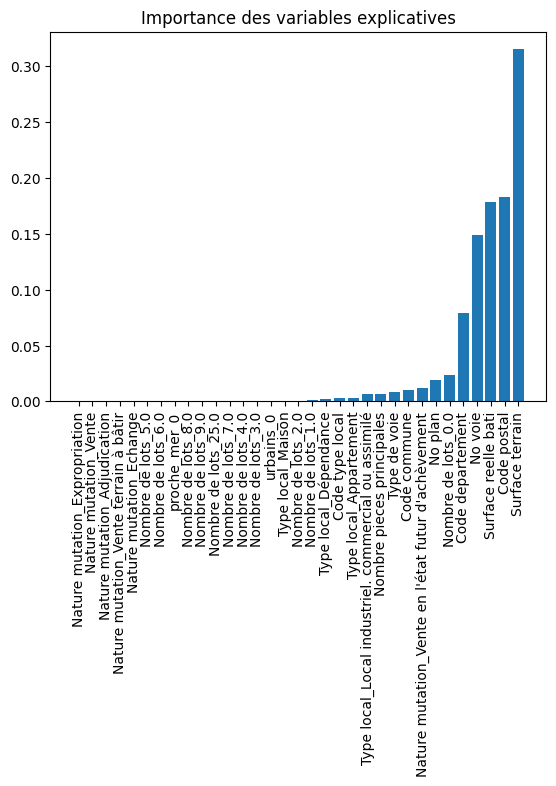

In [87]:
importances = gb.feature_importances_
features = X_train.columns
indices = np.argsort(importances)
sorted_importances = importances[indices]
sorted_features = features[indices]

#Visualisation
plt.bar(sorted_features, sorted_importances)
plt.xticks(rotation=90)
plt.title("Importance des variables explicatives")
plt.show()

### Visualisation des prédictions de notre meilleur modèle

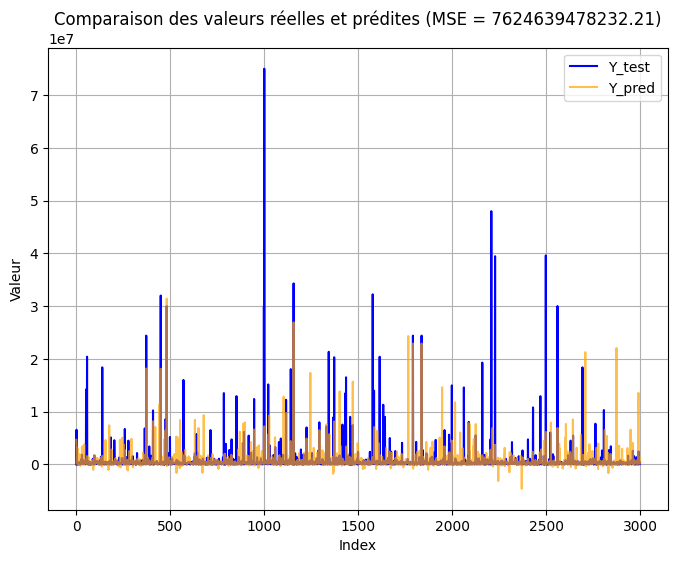

In [92]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calcul du MSE
mse = mean_squared_error(y_test, y_pred_gb)

# Tracer les erreurs au fil du temps
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(y_test)), y_test, label="Y_test", color="blue")
plt.plot(np.arange(len(y_pred_gb)), y_pred_gb, label="Y_pred", color="orange", alpha=0.7)
plt.title(f"Comparaison des valeurs réelles et prédites (MSE = {mse:.2f})")
plt.xlabel("Index")
plt.ylabel("Valeur")
plt.legend()
plt.grid(True)
plt.show()


### Conclusion